# Multi-Modal Summarization: Text vs Audio

This notebook implements the comparison between **Gemma-3N-E2B-it** and **Qwen2.5-Omni-3B** on two modalities: **Text** and **Audio**.

## 1. Setup & Dependencies
First, we install the necessary libraries. Note that we need `edge-tts` for generating audio from the text datasets.

In [25]:
!pip install -q git+https://github.com/huggingface/transformers.git accelerate datasets torchaudio edge-tts rouge_score evaluate scipy soundfile librosa bitsandbytes
!pip install -q nest_asyncio
!pip install -q openai-whisper

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 57.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
import nest_asyncio
from huggingface_hub import login
from google.colab import userdata
import random
import json
import asyncio
import edge_tts
from datasets import load_dataset
from tqdm.asyncio import tqdm
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import librosa

import gc
from typing import Optional, Dict, Any

import torch
from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    AutoConfig,
)

In [ ]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

nest_asyncio.apply()

# Try to get token from Colab secrets, else prompt user
try:
    token = userdata.get('HF_TOKEN')
    login(token)
    print("Logged in via Colab Secret")
except:
    login()

Logged in via Colab Secret


## 2. Data Preparation
We load the **XSum** and **SAMSum** datasets and select a random subset of 500 samples each to keep the runtime manageable.

In [ ]:
# Configuration
NUM_SAMPLES = 20  # Adjust as needed (e.g. 10 for testing)
OUTPUT_DIR = "/content/audio_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def prepare_dataset(dataset_name, split, text_column, summary_column, num_samples):
    print(f"Loading {dataset_name}...")
    ds = load_dataset(dataset_name, split=split)
    # Shuffle and select subset
    ds = ds.shuffle(seed=42).select(range(min(num_samples, len(ds))))

    data = []
    for idx, item in enumerate(ds):
        entry = {
            "id": f"{dataset_name.split('/')[-1]}_{idx}",
            "text": item[text_column],
            "summary": item[summary_column],
            "dataset": dataset_name
        }
        data.append(entry)
    return data

# Load Data
xsum_data = prepare_dataset("xsum", "test", "document", "summary", NUM_SAMPLES)
samsum_data = prepare_dataset("knkarthick/samsum", "test", "dialogue", "summary", NUM_SAMPLES)
all_data = xsum_data + samsum_data
print(f"Total samples: {len(all_data)}")

Loading xsum...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/300M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/16.4M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

...

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

Total samples: 40


In [ ]:
def show_random_samples(dataset_list, num_examples=3):
    if len(dataset_list) < num_examples:
        num_examples = len(dataset_list)

    picks = random.sample(range(len(dataset_list)), num_examples)

    selected_data = []
    for i in picks:
        item = dataset_list[i].copy()
        if len(item['text']) > 1000:
            item['text'] = item['text'][:1000] + "..."
        selected_data.append(item)

    df = pd.DataFrame(selected_data)
    cols = ['id', 'text', 'summary', 'dataset']
    df = df[[c for c in cols if c in df.columns]]

    display(HTML(df.to_html(index=False)))

print("--- XSum Samples ---")
show_random_samples(xsum_data)
print("\n--- SAMSum Samples ---")
show_random_samples(samsum_data)

--- XSum Samples ---


id,text,summary,dataset
xsum_15,"But that requires a very patient man or woman to select the most important periods of play.\nNow scientists in Spain are trying to make that work easier by getting a computer to do it.\nThe technology is being designed to automatically edit a whole game down to the key moments.\nThe people behind it at the Polytechnic University of Catalonia have been working on it for a few years and have just published 18 pages of exactly how it works.\nArnau Raventos is the lead professor on the project.\nHe tells Newsbeat they have ""been working with the local television companies in Spain in order to try to make the job easier for the person who manually does the summaries currently.""\nWithout having to read the full report (we did that for you) - in short - it analyses what are known as key-frames.\nSo, every part of the match is looked over by the computer to spot tell-tale signs of when something interesting is happening.\nThat might be lots of players grouped together, lots of zoomed-in action, extra ...",For years Match of the Day has satisfied impatient football fans by condensing a 90 minute match into a handy chunk of highlights.,xsum
xsum_0,"Sarah Johnson was one of 21 women heading to Liverpool when their minibus was hit by a lorry on the M62.\nHer friend Bethany Jones, 18, was killed while Ms Johnson and several others were badly hurt.\nMinibus driver James Johnson was jailed for more than six years for causing Bethany's death, in April 2013.\nMs Johnson, who broke her shoulder, back and pelvis, said the help she received from a charity while in hospital led her to want to support others.\nSpeaking publicly for the first time about the crash, Ms Johnson described how everyone was ""excited and giddy"" for the hen party.\n""To me the impact was just a massive explosion,"" she said. ""I thought the bus had blown up.\n""I remember the bus dropping on its side. The next thing, I woke up on the roadside so I'd actually come out of the window.""\nMs Johnson was taken to Leeds General Infirmary where she, along with Bethany's sister Amy Firth, underwent major surgery and spent time in intensive care.\nWhilst she was there she got support fro...",A woman who was seriously hurt in a fatal hen party motorway crash is now helping other major trauma victims rebuild their lives.,xsum
xsum_19,"In a speech he said, given the effects of the referendum vote, the government had to be ""realistic about achieving a surplus by the end of the decade"".\nThe target had been the chancellor's most prized goal and had been driving austerity measures in previous budgets.\nBut he said the economy is showing ""clear signs"" of shock following the vote to leave the European Union.\nGiving a speech in Manchester, Mr Osborne said: ""The referendum is expected to produce a significant negative economic shock to our economy. How we respond will determine the impact on jobs and growth.\n""We must provide fiscal credibility, continuing to be tough on the deficit while being realistic about achieving a surplus by the end of the decade.""\nLabour's shadow chancellor John McDonnell welcomed the move, saying: ""Sadly the vote last Thursday for Brexit has only brought forward what was inevitable.\n""The Chancellor had already dropped his other fiscal rules on welfare and debt at the Budget in March, and according to...",Chancellor George Osborne has abandoned his target to restore government finances to a surplus by 2020.,xsum



--- SAMSum Samples ---


id,text,summary,dataset
samsum_15,"Adam: My friend told me he saw Tim with a guy.\nNate: And?\nAdam: <file_photo>\nNate: omg\nJulia: Yeah, what a shocker\nAdam: ??? You knew?!\nJulia: I thought everyone knew\nNate: I had no idea\nNate: Did he tell you anything?\nJulia: That he’s gay? God no\nAdam: Why didn’t you tell us?\nJulia: First: I assumed you knew\nJulia: Second: Why would I? it’s not my business\nNate: I think he should’ve told us ;/ not cool\nAdam: yeah, I made a completely idiot out of myself defending him\nJulia: Against whom? I’m not surprised he didn’t tell you\nNate: Well, it’s not fair, we’re his friends\nJulia: And? Does it change anything?","Julia knew Tim was gay, while Adam and Nate didn't.",knkarthick/samsum
samsum_5,"Mike: who is going for the research trip?\nJake: Me, Florence, Margot and others\nJake: but that's not important\nFlorence: hahah\nMargot: true, we have our nice bunch of people\nMike: so maybe I'll apply too\nJake: but remember it can be harsh in Swazi now\nMike: gosh, Jake, have you realised at least that it's not even Swazi anymore?\nFlorence: hahaha, quite hilarious\nJake: ?\nMargot: they changed the name of the country last year\nJake: what? so what's the name now?\nMargot: Eswatini\nJake: are you kidding me?\nMargot: Jake, it's basic knowledge before the trip LOL","Jake, Florence, Margot and others are going on a research trip to Swazi. The name of the country was changed last year and it's now Eswatini.",knkarthick/samsum
samsum_13,Ulysses: Did you see your grades?\nPeter: Yes. \nUlysses: I got an A\nPeter: Me too\nJulia: B\nMartha: Where can I check them?\nJulia: Online\nJulia: On the course page,"Ulysses and Peter got an A, Julia got a B. The grades are to be checked on the course page.",knkarthick/samsum


### 2.2 Text Explanatory Data Analysis

We analyze the datasets using two key metrics:

1. **Compression Ratio**: The ratio between the number of words in the summary and the number of words in the original text (smaller values indicate higher compression).
2. **Extractive Index (Overlap)**: The percentage of words in the summary that also appear in the original document. It measures how much the summary 'copies' directly from the source versus paraphrasing it.

--- Media per dataset ---


dataset,knkarthick/samsum,xsum
compression_ratio,0.253579,0.118616
extractive_index,0.507885,0.573555
text_chars,555.050000,1872.750000
summary_chars,106.350000,122.500000


--- Massimo numero di caratteri per dataset ---


dataset,knkarthick/samsum,xsum
text_chars,1253,6412
summary_chars,200,190


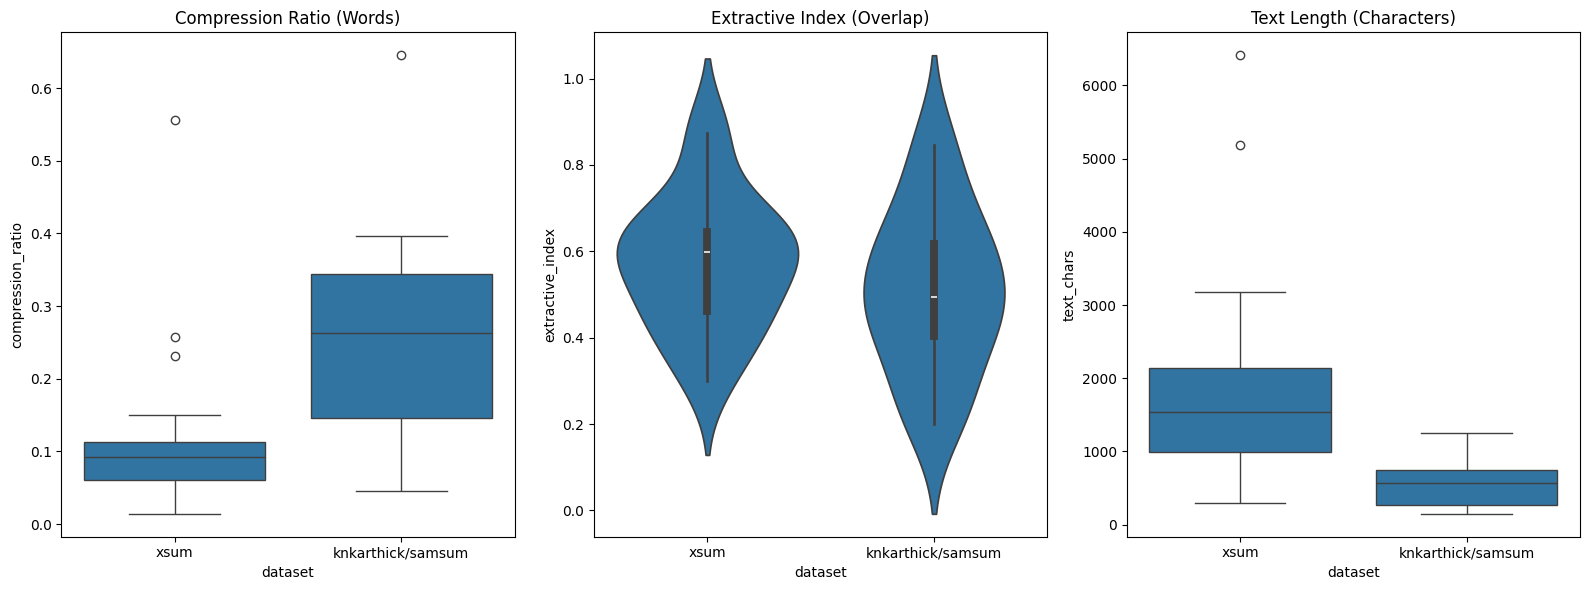

In [ ]:
def text_analysis(data):
    df = pd.DataFrame(data)

    df['text_len'] = df['text'].apply(lambda x: len(x.split()))
    df['summary_len'] = df['summary'].apply(lambda x: len(x.split()))

    df['text_chars'] = df['text'].apply(len)
    df['summary_chars'] = df['summary'].apply(len)

    df['compression_ratio'] = df['summary_len'] / df['text_len']

    def get_overlap(row):
        t_words = set(row['text'].lower().replace('.', '').replace(',', '').split())
        s_words = row['summary'].lower().replace('.', '').replace(',', '').split()
        if not s_words: return 0
        matches = sum(1 for w in s_words if w in t_words)
        return matches / len(s_words)

    df['extractive_index'] = df.apply(get_overlap, axis=1)

    return df


all_df = text_analysis(all_data)

metrics = ['compression_ratio', 'extractive_index', 'text_chars', 'summary_chars']
print("--- Media per dataset ---")
display(all_df.groupby('dataset')[metrics].mean().T)

char_metrics = ['text_chars', 'summary_chars']
print("--- Massimo numero di caratteri per dataset ---")
display(all_df.groupby('dataset')[char_metrics].max().T)

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
sns.boxplot(data=all_df, x='dataset', y='compression_ratio')
plt.title('Compression Ratio (Words)')

plt.subplot(1, 3, 2)
sns.violinplot(data=all_df, x='dataset', y='extractive_index')
plt.title('Extractive Index (Overlap)')

plt.subplot(1, 3, 3)
sns.boxplot(data=all_df, x='dataset', y='text_chars')
plt.title('Text Length (Characters)')

plt.tight_layout()
plt.show()

### Audio Generation
Now we generate audio files for each document using `edge-tts`. This simulates the 'audio document' modality.

In [ ]:
async def generate_audio(text, output_path):
    voice = "en-US-AriaNeural" # High quality English voice
    communicate = edge_tts.Communicate(text, voice)
    await communicate.save(output_path)

async def process_batch(data_items):
    tasks = []
    for item in data_items:
        file_path = os.path.join(OUTPUT_DIR, f"{item['id']}.mp3")
        item['audio_path'] = file_path
        if not os.path.exists(file_path):
            # Limit text length to avoid TTS errors on extremely long docs if necessary
            # For now, we try full text.
            tasks.append(generate_audio(item['text'][:3000], file_path))

    if tasks:
        # Run with a semaphore to avoid overloading the TTS service
        # Since edge-tts is a library wrapping a websocket, we can run a few concurrently
        await asyncio.gather(*tasks)

async def main():
    batch_size = 10
    for i in tqdm(range(0, len(all_data), batch_size), desc="Generating Audio"):
        batch = all_data[i:i+batch_size]
        await process_batch(batch)
await main()

Generating Audio: 100%|██████████| 4/4 [00:00<00:00, 4580.18it/s]


### 2.3 Audio Explanatory Data Analysis

Analyzing Audio: 100%|██████████| 40/40 [00:01<00:00, 25.29it/s]

--- Audio Statistics (Mean) ---


dataset,knkarthick/samsum,xsum
duration,51.589200,112.650000
words_per_second,1.916863,2.704452


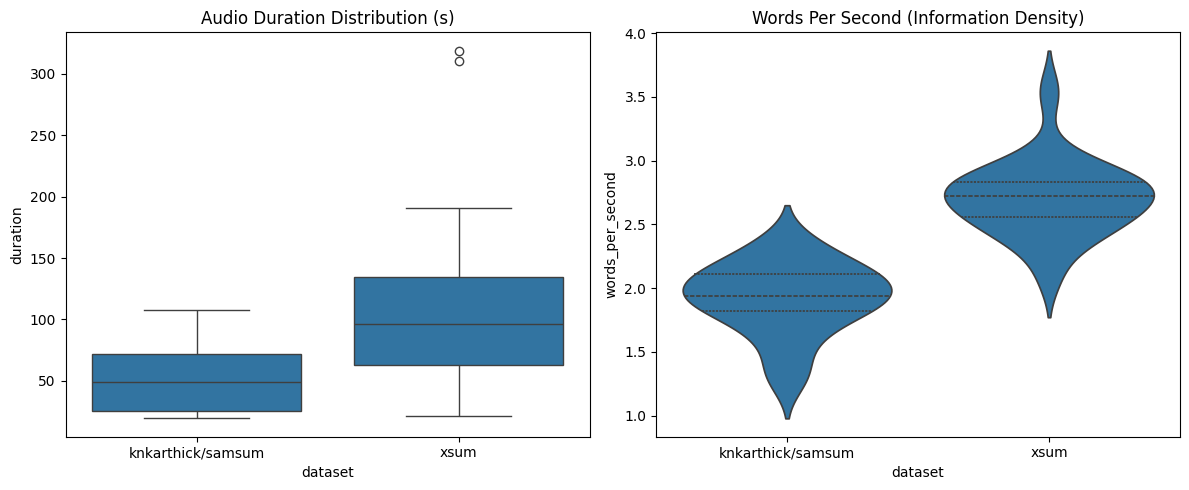

Average duration: 82.12s
Average density (WPS): 2.31 words/sec


In [ ]:
def audio_analysis(data):
    records = []
    # Sample for analysis to save time
    analysis_subset = random.sample(data, min(len(data), 100))
    for item in tqdm(analysis_subset, desc="Analyzing Audio"):
        if os.path.exists(item['audio_path']):
            y, sr = librosa.load(item['audio_path'], sr=None)
            dur = librosa.get_duration(y=y, sr=sr)
            # WPS: Information density (words per second of audio)
            wps = len(item['text'].split()) / dur if dur > 0 else 0

            records.append({
                'dataset': item['dataset'],
                'duration': dur,
                'words_per_second': wps
            })
    return pd.DataFrame(records)

audio_df = audio_analysis(all_data)

if not audio_df.empty:
    print("--- Audio Statistics (Mean) ---")
    display(audio_df.groupby('dataset')[['duration', 'words_per_second']].mean().T)

    plt.figure(figsize=(12, 5))

    # 1. Duration Split by Dataset
    plt.subplot(1, 2, 1)
    sns.boxplot(data=audio_df, x='dataset', y='duration')
    plt.title('Audio Duration Distribution (s)')

    # 2. Information Density (WPS)
    plt.subplot(1, 2, 2)
    sns.violinplot(data=audio_df, x='dataset', y='words_per_second', inner="quart")
    plt.title('Words Per Second (Information Density)')

    plt.tight_layout()
    plt.show()

    print(f"Average duration: {audio_df['duration'].mean():.2f}s")
    print(f"Average density (WPS): {audio_df['words_per_second'].mean():.2f} words/sec")

## 3. Models & Inference
We will implement a generic `Evaluator` class that handles loading models and running inference.
Since we are on Colab (likely T4 GPU), we might not be able to load both models simultaneously. We will structure the code to load one, run inference, and then unload it.

In [ ]:
def flush_memory():
    gc.collect()
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass


class ModelInference:
    """
    Classe unificata per inferenza di summarization testo/audio per due tipi di modelli:
      - model_type == 'qwen'  -> usa AutoProcessor (testo+audio multimodale)
      - model_type == 'gemma' -> usa AutoTokenizer + AutoModelForCausalLM (testo)

    Metodi principali:
      - load()
      - unload()
      - summarize_text(text, max_new_tokens=128, decoding='greedy', max_input_length=1024)
      - summarize_audio(audio_path, ...)  -> usa processor (Qwen) o speech-to-text fallback (Gemma via whisper)
    """

    def __init__(self, model_name: str, model_type: str):
        assert model_type in ("qwen", "gemma")
        self.model_name = model_name
        self.model_type = model_type
        self.model = None
        self.processor = None
        self.tokenizer = None
        self.device = None

    def load(self):
        """
        Carica il modello in memoria (quantizzato in 4-bit se possibile).
        """
        print(f"Loading {self.model_name} ({self.model_type}) ...")
        flush_memory()

        quant_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

        if self.model_type == "qwen":
            # processor multimodale
            self.processor = AutoProcessor.from_pretrained(self.model_name, trust_remote_code=True)

            tok = self.processor.tokenizer
            if tok.pad_token is None:
                tok.pad_token = tok.eos_token

            config = AutoConfig.from_pretrained(self.model_name, trust_remote_code=True)
            if hasattr(config, "talker_config"):
                tc = config.talker_config
                if not hasattr(tc, "pad_token_id"):
                    tc.pad_token_id = 0

            # Proviamo a importare una classe specifica se disponibile
            try:
                from transformers import Qwen2_5OmniForConditionalGeneration
                ModelClass = Qwen2_5OmniForConditionalGeneration
            except Exception:
                from transformers import AutoModelForCausalLM as AM
                ModelClass = AM

            self.model = ModelClass.from_pretrained(
                self.model_name,
                config=config,
                device_map="auto",
                quantization_config=quant_cfg,
                low_cpu_mem_usage=True,
                trust_remote_code=True,
            )

        elif self.model_type == "gemma":
            # tokenizer + causal LM
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_name,
                device_map="auto",
                quantization_config=quant_cfg,
                low_cpu_mem_usage=True,
            )

        # Determina device (fallback se model è sharded)
        try:
            # se il modello è distribuito, next(self.model.parameters()).device dà un device valido
            self.device = next(self.model.parameters()).device
        except Exception:
            # fallback generico
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        print(f"Loaded on device: {self.device}")

    def unload(self):
        """
        Rimuove risorse e libera memoria GPU.
        """
        print(f"Unloading {self.model_name} ...")
        try:
            del self.model
        except Exception:
            pass
        try:
            if self.processor:
                del self.processor
        except Exception:
            pass
        try:
            if self.tokenizer:
                del self.tokenizer
        except Exception:
            pass

        self.model = None
        self.processor = None
        self.tokenizer = None
        flush_memory()
        print("Unloaded and memory flushed.")

    # -------------------------
    # UTIL: pulizia output
    # -------------------------
    @staticmethod
    def _strip_prompt(output: str, prompt: str) -> str:
        if output.startswith(prompt):
            return output[len(prompt):].strip()
        # fallback: se il prompt appare più avanti, non rimuovere a meno che non sia prefisso
        return output.strip()

    @staticmethod
    def _safe_extract_generated_ids(generated):
        # In alcuni modelli generate ritorna (ids, something). Normalizziamo
        if isinstance(generated, tuple):
            return generated[0]
        return generated

    # -------------------------
    # Summarize text
    # -------------------------
    def summarize_text(
        self,
        text: str,
        max_new_tokens: int = 128,
        decoding: str = "greedy",
        max_input_length: int = 1024,
        prompt_template: Optional[str] = None,
        **generate_kwargs,
    ) -> str:
        """
        Riassume un testo.
        - decoding: 'greedy' o 'beam'
        - max_input_length: tokens / context per l'encoder / processor (default 1024)
        - prompt_template: opzionale, stringa con un placeholder {text}; se None usa default
        - generate_kwargs: parametri addizionali passati a model.generate
        """

        if prompt_template is None:
            prompt = f"Summarize the following text:\n\n{text}\n\nSummary:"
        else:
            prompt = prompt_template.format(text=text)

        if self.model is None:
            raise RuntimeError("Model non caricato. Chiamare load() prima.")

        # Preparazione degli inputs
        if self.model_type == "qwen":
            if self.processor is None:
                raise RuntimeError("Processor non disponibile per Qwen.")
            inputs = self.processor(
                text=prompt,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_input_length,
            ).to(self.device)
        else:  # gemma
            if self.tokenizer is None:
                raise RuntimeError("Tokenizer non disponibile per Gemma.")
            inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True).to(self.device)

        # parametri di generazione
        gen_kwargs: Dict[str, Any] = {}
        gen_kwargs.update({"max_new_tokens": max_new_tokens})
        if decoding == "beam":
            gen_kwargs.update({"num_beams": generate_kwargs.pop("num_beams", 5), "early_stopping": True})
        # allow user override/additional args
        gen_kwargs.update(generate_kwargs)

        # generate
        generated = self.model.generate(**inputs, **gen_kwargs)
        gen_ids = self._safe_extract_generated_ids(generated)

        # decode in modo sicuro
        if self.model_type == "qwen":
            decoded = self.processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
            decoded = self._strip_prompt(decoded, prompt)
        else:  # gemma
            decoded = self.tokenizer.decode(gen_ids[0], skip_special_tokens=True)
            decoded = decoded.replace(prompt, "").strip()

        return decoded

    # -------------------------
    # Summarize audio
    # -------------------------
    def summarize_audio(
        self,
        audio_path: str,
        max_new_tokens: int = 128,
        decoding: str = "greedy",
        max_input_length: int = 1024,
        prompt_template: Optional[str] = None,
        stt_model: str = "small",  # modello whisper fallback per Gemma
        **generate_kwargs,
    ) -> str:
        """
        Riassume un file audio.
        - Per Qwen: invia (text prompt + audio) al processor + model se il processor supporta audio.
        - Per Gemma: se il modello non supporta audio, viene effettuata trascrizione con whisper (richiede la libreria `whisper` installata),
          poi si riassume il testo risultante con summarize_text.
        - stt_model: nome modello whisper da usare come fallback (es. 'small', 'base', 'tiny' ecc.)
        """

        if prompt_template is None:
            prompt = "Summarize this audio."
        else:
            prompt = prompt_template.format(path=audio_path)

        if self.model is None:
            raise RuntimeError("Model non caricato. Chiamare load() prima.")

        # ----- QWEN path (multimodale) -----
        if self.model_type == "qwen":
            if self.processor is None:
                raise RuntimeError("Processor non disponibile per Qwen audio path.")
            import librosa
            # carica audio alla sampling_rate attesa dal processor (se definita)
            target_sr = getattr(self.processor.feature_extractor, "sampling_rate", None)
            audio, sr = librosa.load(audio_path, sr=target_sr)
            audio = audio.astype("float32")

            inputs = self.processor(
                text=prompt,
                audio=audio,
                return_tensors="pt",
                sampling_rate=sr,
            ).to(self.device)

            gen_kwargs: Dict[str, Any] = {}
            gen_kwargs.update({"max_new_tokens": max_new_tokens})
            if decoding == "beam":
                gen_kwargs.update({"num_beams": generate_kwargs.pop("num_beams", 5), "early_stopping": True})
            gen_kwargs.update(generate_kwargs)

            generated = self.model.generate(**inputs, **gen_kwargs)
            gen_ids = self._safe_extract_generated_ids(generated)
            output = self.processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
            output = self._strip_prompt(output, prompt)
            return output

        # ----- GEMMA path (no native audio support) -----
        elif self.model_type == "gemma":
            # Fallback: trascrizione audio con whisper se disponibile, altrimenti errore informativo.
            try:
                import whisper
            except Exception as e:
                raise ImportError(
                    "Per usare summarize_audio con model_type='gemma' è necessario avere 'whisper' installato. "
                    "Installa con: pip install -U openai-whisper  (oppure fornisci un modello multimodale)."
                ) from e

            # Carica modello whisper (leggero per velocità, parametro stt_model configurabile)
            stt = whisper.load_model(stt_model)
            # Transcribe (usa la funzione di whisper che accetta filepath)
            result = stt.transcribe(audio_path)
            transcript = result.get("text", "").strip()
            if not transcript:
                raise RuntimeError("Trascrizione vuota o fallita con whisper fallback.")

            # Ora riassumi il transcript con summarize_text
            # Nota: usiamo lo stesso prompt_template ma sostituiamo il testo
            return self.summarize_text(
                text=transcript,
                max_new_tokens=max_new_tokens,
                decoding=decoding,
                max_input_length=max_input_length,
                prompt_template=prompt_template or "Summarize the following text:\n\n{text}\n\nSummary:",
                **generate_kwargs,
            )


## 4. Inference with greedy decoding


### 4.1 Qwen

In [ ]:
from tqdm import tqdm
import json
import torch

TEST_LIMIT = 5  # Set to None for full run
data_subset = all_data[:TEST_LIMIT] if TEST_LIMIT else all_data

# --- Run Qwen ---
if 'qwen' in globals():
    print('Cleaning up previous qwen instance...')
    try: qwen.unload()
    except: pass
    del qwen
    flush_memory()

qwen = ModelInference("Qwen/Qwen2.5-Omni-3B", "qwen")
qwen.load()

for item in tqdm(data_subset, desc="Qwen Inference"):
    try:
        # --- Text Summary ---
        text_input = item.get('text', "")
        t_sum = qwen.generate_text_summary(text_input)

        # --- Audio Summary ---
        audio_path = item.get('audio_path', None)
        if audio_path:
            a_sum = qwen.generate_audio_summary(audio_path)
        else:
            a_sum = "[No audio file provided]"

        # --- Save results into item ---
        item['qwen_text_summary'] = t_sum
        item['qwen_audio_summary'] = a_sum

    except Exception as e:
        print(f"Error processing {item.get('id', 'unknown')}: {e}")
        # Optionally, save partial results
        item['qwen_text_summary'] = ""
        item['qwen_audio_summary'] = ""

qwen.unload()

# --- Save final results ---
with open("/content/results.json", "w") as f:
    json.dump(data_subset, f, ensure_ascii=False, indent=2)

print("Qwen inference completed and results saved.")


Cleaning up previous qwen instance...
Loading Qwen/Qwen2.5-Omni-3B...


Loading weights:   0%|          | 0/2543 [00:00<?, ?it/s]

Qwen2_5OmniForConditionalGeneration LOAD REPORT from: Qwen/Qwen2.5-Omni-3B
Key                                                | Status     |  | 
---------------------------------------------------+------------+--+-
token2wav.code2wav_dit_model.rotary_embed.inv_freq | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Qwen Inference:   0%|          | 0/5 [02:59<?, ?it/s]


KeyboardInterrupt: 

### 4.2 Gemma

In [ ]:
from tqdm import tqdm
import json
import torch

TEST_LIMIT = 5  # Set to None for full run
data_subset = all_data[:TEST_LIMIT] if TEST_LIMIT else all_data

# --- Pulizia eventuali istanze precedenti ---
if 'gemma' in globals():
    print("Cleaning up previous gemma instance...")
    try:
        gemma.unload()
    except Exception:
        pass
    del gemma
    flush_memory()

# --- Carica modello Gemma (italiano) ---
model_name = "google/gemma-3n-E2B-it"
gemma = ModelInference(model_name, "gemma")
gemma.load()

# --- Loop inferenza ---
for item in tqdm(data_subset, desc="Gemma Inference (Greedy)"):
    try:
        # --- Text Summary ---
        text_input = item.get("text", "")
        t_sum = gemma.summarize_text(
            text=text_input,
            max_new_tokens=128,
            decoding="greedy"  # greedy search
        )

        # --- Audio Summary ---
        audio_path = item.get("audio_path", None)
        if audio_path:
            # Summarize audio; fallback via whisper se Gemma non supporta audio nativo
            a_sum = gemma.summarize_audio(
                audio_path,
                max_new_tokens=128,
                decoding="greedy"
            )
        else:
            a_sum = "[No audio file provided]"

        # --- Salva risultati nell'item ---
        item["gemma_text_summary"] = t_sum
        item["gemma_audio_summary"] = a_sum

    except Exception as e:
        print(f"Error processing {item.get('id', 'unknown')}: {e}")
        item["gemma_text_summary"] = ""
        item["gemma_audio_summary"] = ""

# --- Scarica modello e libera memoria ---
gemma.unload()

# --- Salva risultati finali ---
with open("/content/gemma_results_greedy.json", "w") as f:
    json.dump(data_subset, f, ensure_ascii=False, indent=2)

print("Gemma inference (greedy) completed and results saved.")


Cleaning up previous gemma instance...
Unloading gemma-model-name ...
Unloaded and memory flushed.
Loading google/gemma-3n-E2B-it (gemma) ...


config.json:   0%|          | 0.00/4.25k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/769 [00:00<?, ?B/s]

...

Gemma Inference (Greedy):  80%|████████  | 4/5 [01:12<00:20, 20.49s/it]

Error processing xsum_3: Per usare summarize_audio con model_type='gemma' è necessario avere 'whisper' installato. Installa con: pip install -U openai-whisper  (oppure fornisci un modello multimodale).


Gemma Inference (Greedy): 100%|██████████| 5/5 [01:21<00:00, 16.21s/it]

Error processing xsum_4: Per usare summarize_audio con model_type='gemma' è necessario avere 'whisper' installato. Installa con: pip install -U openai-whisper  (oppure fornisci un modello multimodale).
Unloading google/gemma-3n-E2B-it ...


Unloaded and memory flushed.
Gemma inference (greedy) completed and results saved.


## 5. Evaluation


### Qualitative evaluation

#### -- gemma greedy decoding

In [23]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/TextMiningProject/gemma_results_greedy.json'

with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print("\n--- Gemma greedy results ---")
print("\n--- Results comparison with gold standard ---")
N = 5
for i, row in df.head(N).iterrows():
    print(f"\nID: {row['id']}")
    print("Gold summary:")
    print(row['summary'])
    print("\nGemma summary:")
    print(row['gemma_text_summary'])
    print("-" * 80)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Gemma greedy results ---

--- Results comparison with gold standard ---

ID: xsum_0
Gold summary:
A woman who was seriously hurt in a fatal hen party motorway crash is now helping other major trauma victims rebuild their lives.

Gemma summary:

--------------------------------------------------------------------------------

ID: xsum_1
Gold summary:
A Tudor manor house has reopened following a £2.2m makeover.

Gemma summary:

--------------------------------------------------------------------------------

ID: xsum_2
Gold summary:
Walt Disney World has unveiled a lighthouse memorial for a young boy who was killed by an alligator while on holiday at the Florida theme park.

Gemma summary:

--------------------------------------------------------------------------------

ID: xsum_3
Gold summary:
The agriculture minister is to return to China next month as 

### Quantitative evaluation

#### -- gemma greedy decoding

In [24]:
rouge = evaluate.load("rouge")

records = []

# --- Dataset di riferimento (puoi usare df o data_subset) ---
for item in data_subset:
    ref = item['summary']

    # --- Qwen Scores (se vuoi tenerli) ---
    if 'qwen_text_summary' in item:
        s_text = rouge.compute(predictions=[item['qwen_text_summary']], references=[ref])
        s_audio = rouge.compute(predictions=[item['qwen_audio_summary']], references=[ref])

        records.append({"Model": "Qwen", "Modality": "Text", "ROUGE-1": s_text['rouge1'], "ROUGE-L": s_text['rougeL']})
        records.append({"Model": "Qwen", "Modality": "Audio", "ROUGE-1": s_audio['rouge1'], "ROUGE-L": s_audio['rougeL']})

    # --- Gemma Scores ---
    if 'gemma_text_summary' in item:
        s_text = rouge.compute(predictions=[item['gemma_text_summary']], references=[ref])
        records.append({"Model": "Gemma", "Modality": "Text", "ROUGE-1": s_text['rouge1'], "ROUGE-L": s_text['rougeL']})

    if 'gemma_audio_summary' in item:
        # verifica che non sia vuoto
        if item['gemma_audio_summary'] not in [None, "", "[No audio file provided]"]:
            s_audio = rouge.compute(predictions=[item['gemma_audio_summary']], references=[ref])
            records.append({"Model": "Gemma", "Modality": "Audio", "ROUGE-1": s_audio['rouge1'], "ROUGE-L": s_audio['rougeL']})

# --- Trasforma in DataFrame ---
df_scores = pd.DataFrame(records)

# --- Statistiche medie ---
print(df_scores.groupby(["Model", "Modality"]).mean())

# --- Boxplot ROUGE-1 ---
df_scores.boxplot(column='ROUGE-1', by=['Model', 'Modality'], figsize=(10,6))

NameError: name 'evaluate' is not defined

In [ ]:
import evaluate
import pandas as pd

rouge = evaluate.load("rouge")

records = []

for item in data_subset:
    ref = item['summary']

    # Qwen Scores
    if 'qwen_text_summary' in item:
        s_text = rouge.compute(predictions=[item['qwen_text_summary']], references=[ref])
        s_audio = rouge.compute(predictions=[item['qwen_audio_summary']], references=[ref])

        records.append({"Model": "Qwen", "Modality": "Text", "ROUGE-1": s_text['rouge1'], "ROUGE-L": s_text['rougeL']})
        records.append({"Model": "Qwen", "Modality": "Audio", "ROUGE-1": s_audio['rouge1'], "ROUGE-L": s_audio['rougeL']})

df = pd.DataFrame(records)
print(df.groupby(["Model", "Modality"]).mean())

# Boxplot
df.boxplot(column='ROUGE-1', by=['Model', 'Modality'], figsize=(10,6))